In [1]:
# processing json images for pretraining splits 
import json 
import os


In [2]:
with open('/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_Autopet/splits_final.json', 'r') as f:
    original_data_splits = json.load(f)

# fold_1_psma = data[1]

# with open('./nnUNet_processed/Dataset888_Autopet/splits_final_fdg.json', 'r') as f:
#     data = json.load(f)

# with open('./nnUNet_processed/Dataset888_Autopet/splits_final.json', 'r') as f:
#     combined_data = json.load(f)

# fold_1_fdg = data[1]

In [28]:
# read json file 
import json 

percents = [1, 5, 10, 20, 30]
old_percentile_trains = []

for percent in percents: 
    with open(f'/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_Autopet/splits_final_{percent}_percent.json', 'r') as f:
        curr_data = json.load(f)
        print(len(curr_data))
        for idx, dat in enumerate(curr_data):
            if type(dat) is not int: 
                if len(dat) < 2:
                    continue
                print(f'Percent: {percent} - Fold: {idx} - Number of files: {len(dat["train"])}')
                old_percentile_trains.append(dat['train'])
            
# with open(f'/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset903_AutoPet/splits_final.json', 'r') as f:
#     data_903_5 = json.load(f)

# with open(f'/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset902_AutoPet/splits_final.json', 'r') as f:
#     data_902 = json.load(f)

2
Percent: 1 - Fold: 1 - Number of files: 9
2
Percent: 5 - Fold: 1 - Number of files: 51
1
Percent: 10 - Fold: 0 - Number of files: 103
2
Percent: 20 - Fold: 1 - Number of files: 207
1
Percent: 30 - Fold: 0 - Number of files: 312


In [29]:


# count how many have psma and how many have fdg in the final json
psma_files = [x for x in data[6]['train'] if 'psma' in x]
fdg_files = [x for x in data[6]['train'] if 'fdg' in x]
print(f'Number of psma files in final json: {len(psma_files)}')
print(f'Number of fdg files in final json: {len(fdg_files)}')
print(f'Total files in final json: {len(data[6]["train"])}')

Number of psma files in final json: 379
Number of fdg files in final json: 664
Total files in final json: 1043


In [30]:
unity_dataset = []

PERCENTAGES = [1, 5, 10, 11, 15, 20, 30, 100]
for p in PERCENTAGES:
    temp_psma_files = psma_files[:int(len(psma_files)*p/100)]
    temp_fdg_files = fdg_files[:int(len(fdg_files)*p/100)]
    print(f'Percentage: {p}% - Number of psma files: {len(temp_psma_files)} - Number of fdg files: {len(temp_fdg_files)} - Total files: {len(temp_psma_files) + len(temp_fdg_files)}')
    new_fold = {'train': temp_psma_files + temp_fdg_files, 'val': data[6]['val']}
    unity_dataset.append(new_fold)



Percentage: 1% - Number of psma files: 3 - Number of fdg files: 6 - Total files: 9
Percentage: 5% - Number of psma files: 18 - Number of fdg files: 33 - Total files: 51
Percentage: 10% - Number of psma files: 37 - Number of fdg files: 66 - Total files: 103
Percentage: 11% - Number of psma files: 41 - Number of fdg files: 73 - Total files: 114
Percentage: 15% - Number of psma files: 56 - Number of fdg files: 99 - Total files: 155
Percentage: 20% - Number of psma files: 75 - Number of fdg files: 132 - Total files: 207
Percentage: 30% - Number of psma files: 113 - Number of fdg files: 199 - Total files: 312
Percentage: 100% - Number of psma files: 379 - Number of fdg files: 664 - Total files: 1043


In [31]:
for entry in unity_dataset:
    print(f'Number of psma files: {len([x for x in entry["train"] if "psma" in x])} - Number of fdg files: {len([x for x in entry["train"] if "fdg" in x])} - Total files: {len(entry["train"])}')

Number of psma files: 3 - Number of fdg files: 6 - Total files: 9
Number of psma files: 18 - Number of fdg files: 33 - Total files: 51
Number of psma files: 37 - Number of fdg files: 66 - Total files: 103
Number of psma files: 41 - Number of fdg files: 73 - Total files: 114
Number of psma files: 56 - Number of fdg files: 99 - Total files: 155
Number of psma files: 75 - Number of fdg files: 132 - Total files: 207
Number of psma files: 113 - Number of fdg files: 199 - Total files: 312
Number of psma files: 379 - Number of fdg files: 664 - Total files: 1043


In [42]:
# dump unity dataset to json
with open('unity_dataset_splits.json', 'w') as f:
    json.dump(unity_dataset, f, indent=4)

In [39]:

count = 0 
indices = [0, 1, 2, 5, 6]
for i in indices:
    if unity_dataset[i]['train'] == old_percentile_trains[count]:
        print(f'Fold {i} matches!')
    count += 1
    

Fold 0 matches!
Fold 1 matches!
Fold 2 matches!
Fold 5 matches!
Fold 6 matches!


In [37]:
assert unity_dataset[0]['train'] == old_percentile_trains[0]
assert unity_dataset[1]['train'] == old_percentile_trains[1]
assert unity_dataset[2]['train'] == old_percentile_trains[2]
assert unity_dataset[5]['train'] == old_percentile_trains[3]
assert unity_dataset[6]['train'] == old_percentile_trains[4]


In [16]:
# new_dataset = data + [{'train': ['test test']}] + [original_data_splits[1]]
# # I want it to be fold index 6, so fold 5 is empty
# import the old dataset and see if the unity ones match up 
for thing in old_percentile_splits: 
    if type(thing) is not int: 
        print(len(thing['train']))        

103
103
103
103
103
1043
251
399
547
695


In [11]:
new_dataset

{'train': ['psma_ddd1dd20149915fb_2019-05-27',
  'psma_f954cb7aa70b9dc2_2020-11-16',
  'psma_46cf1282a7648712_2019-04-19',
  'psma_4da96443cf212c5f_2020-08-31',
  'psma_7a522636008cf840_2020-07-31',
  'psma_0bf6ac34fa0c97c0_2017-07-07',
  'psma_652cdc5859bf667d_2017-04-28',
  'psma_8b9bd3dbbb1553f1_2019-02-02',
  'psma_37328a98c70706f3_2020-11-06',
  'psma_798b3279d6980a3b_2019-08-02',
  'psma_7e25beff54698eb8_2021-06-21',
  'psma_823a3a884418928b_2019-12-23',
  'psma_652cdc5859bf667d_2016-03-26',
  'psma_838c9340e85ca431_2015-05-31',
  'psma_416d9ff3295dafcb_2020-02-08',
  'psma_dc8b0fa3643a6878_2019-01-26',
  'psma_fd142797eb926383_2018-09-15',
  'psma_24f62f21c04402ec_2015-04-26',
  'psma_e3c4639102fe5c51_2020-09-25',
  'psma_53c3a9d0f51745b6_2018-05-19',
  'psma_b5a4134e681683c0_2018-10-05',
  'psma_313ff961c59ee5dc_2015-11-13',
  'psma_4c9d9614d81f3005_2019-10-04',
  'psma_b361fb9c2455deb9_2018-11-19',
  'psma_6c6ce41bbf51580b_2019-07-27',
  'psma_ede705184679888a_2017-02-26',
  '

In [ ]:
# assert new_dataset[0] == new_dataset[1] == new_dataset[2] == new_dataset[3] == new_dataset[4] 
# data[0]['train' ] == data[1]['train'] == data[2]['train'] == data[3]['train'] == data[4]['train']

{'train': ['psma_ddd1dd20149915fb_2019-05-27',
  'psma_f954cb7aa70b9dc2_2020-11-16',
  'psma_46cf1282a7648712_2019-04-19',
  'psma_4da96443cf212c5f_2020-08-31',
  'psma_7a522636008cf840_2020-07-31',
  'psma_0bf6ac34fa0c97c0_2017-07-07',
  'psma_652cdc5859bf667d_2017-04-28',
  'psma_8b9bd3dbbb1553f1_2019-02-02',
  'psma_37328a98c70706f3_2020-11-06',
  'psma_798b3279d6980a3b_2019-08-02',
  'psma_7e25beff54698eb8_2021-06-21',
  'psma_823a3a884418928b_2019-12-23',
  'psma_652cdc5859bf667d_2016-03-26',
  'psma_838c9340e85ca431_2015-05-31',
  'psma_416d9ff3295dafcb_2020-02-08',
  'psma_dc8b0fa3643a6878_2019-01-26',
  'psma_fd142797eb926383_2018-09-15',
  'psma_24f62f21c04402ec_2015-04-26',
  'psma_e3c4639102fe5c51_2020-09-25',
  'psma_53c3a9d0f51745b6_2018-05-19',
  'psma_b5a4134e681683c0_2018-10-05',
  'psma_313ff961c59ee5dc_2015-11-13',
  'psma_4c9d9614d81f3005_2019-10-04',
  'psma_b361fb9c2455deb9_2018-11-19',
  'psma_6c6ce41bbf51580b_2019-07-27',
  'psma_ede705184679888a_2017-02-26',
  '

In [12]:
for i in range(len(new_dataset)):
    try: 
        print(len(new_dataset[i]['train']))
    except TypeError:
        print(f"Int")

KeyError: 0

In [ ]:
import pandas as pd
from copy import deepcopy

# Load all quartile CSVs
q1_df = pd.read_csv('./Q1_Low_uncertainty_cases.csv')
q2_df = pd.read_csv('./Q2_uncertainty_cases.csv')
q3_df = pd.read_csv('./Q3_uncertainty_cases.csv')
q4_df = pd.read_csv('./Q4_High_uncertainty_cases.csv')

def get_quartile_cases(input_df):

    # Q1 - Only lowest uncertainty cases added to training
    q1 = deepcopy(input_df[0])
    q1['train'] += input_df['filename'].tolist()
    # Q2 - Q1 + Q2 cases
    q2 = deepcopy(input_df[0])
    q2['train'] += q1_df['filename'].tolist()
    q2['train'] += q2_df['filename'].tolist()

    # Q3 - Q1 + Q2 + Q3 cases
    q3 = deepcopy(data[0])
    q3['train'] += q1_df['filename'].tolist()
    q3['train'] += q2_df['filename'].tolist()
    q3['train'] += q3_df['filename'].tolist()

    # Q4 - All cases (Q1 + Q2 + Q3 + Q4)
    q4 = deepcopy(data[0])
    q4['train'] += q1_df['filename'].tolist()
    q4['train'] += q2_df['filename'].tolist()
    q4['train'] += q3_df['filename'].tolist()
    q4['train'] += q4_df['filename'].tolist()

    # Verify counts
    print(f"Base training cases : {len(data[0]['train'])}")
    print(f"Q1 training cases   : {len(q1['train'])}")
    print(f"Q2 training cases   : {len(q2['train'])}")
    print(f"Q3 training cases   : {len(q3['train'])}")
    print(f"Q4 training cases   : {len(q4['train'])}")

Base training cases : 103
Q1 training cases   : 251
Q2 training cases   : 399
Q3 training cases   : 547
Q4 training cases   : 695


In [ ]:
import pandas as pd
import json
from copy import deepcopy

# Load all quartile CSVs
q1_df = pd.read_csv('./Q1_Low_uncertainty_cases.csv')
q2_df = pd.read_csv('./Q2_uncertainty_cases.csv')
q3_df = pd.read_csv('./Q3_uncertainty_cases.csv')
q4_df = pd.read_csv('./Q4_High_uncertainty_cases.csv')

# Load splits
data = data_902

def get_quartile_cases(data, i):
    """
    Returns a JSON-style list of splits where:
    - Split 0 : identical to the original input split (base labelled only)
    - Split 1 : base + Q1 cases (lowest uncertainty)
    - Split 2 : base + Q1 + Q2 cases
    - Split 3 : base + Q1 + Q2 + Q3 cases
    - Split 4 : base + Q1 + Q2 + Q3 + Q4 cases (all)
    """

    base_train = data[i]['train']  # base labelled training cases
    base_val   = data[i]['val']    # keep val identical across all splits

    # Split 0 - identical to original
    split_0 = deepcopy(data[i])

    # Split 1 - base + Q1
    split_1 = deepcopy(data[i])
    split_1['train'] = base_train + q1_df['filename'].tolist()

    # Split 2 - base + Q1 + Q2
    split_2 = deepcopy(data[i])
    split_2['train'] = base_train + q1_df['filename'].tolist() \
                                  + q2_df['filename'].tolist()

    # Split 3 - base + Q1 + Q2 + Q3
    split_3 = deepcopy(data[i])
    split_3['train'] = base_train + q1_df['filename'].tolist() \
                                  + q2_df['filename'].tolist() \
                                  + q3_df['filename'].tolist()

    # Split 4 - base + Q1 + Q2 + Q3 + Q4
    split_4 = deepcopy(data[i])
    split_4['train'] = base_train + q1_df['filename'].tolist() \
                                  + q2_df['filename'].tolist() \
                                  + q3_df['filename'].tolist() \
                                  + q4_df['filename'].tolist()

    # Verify counts
    print(f"Split 0 - Base only : {len(split_0['train'])}")
    print(f"Split 1 - Base + Q1 : {len(split_1['train'])}")
    print(f"Split 2 - Base + Q2 : {len(split_2['train'])}")
    print(f"Split 3 - Base + Q3 : {len(split_3['train'])}")
    print(f"Split 4 - Base + Q4 : {len(split_4['train'])}")

    output_splits = [split_0, split_1, split_2, split_3, split_4]

    return output_splits


# output_splits = get_quartile_cases(data, 1)
# NEW_DATASET_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset903_AutoPet/'
# # Save to JSON
# OUTPUT_SPLITS_DIR = os.path.join(NEW_DATASET_DIR, 'splits_final.json')
# with open(OUTPUT_SPLITS_DIR, 'w') as f:
#     json.dump(output_splits, f, indent=4)

# print(f'\nSaved splits to: {OUTPUT_SPLITS_DIR}')

Split 0 - Base only : 150
Split 1 - Base + Q1 : 298
Split 2 - Base + Q2 : 446
Split 3 - Base + Q3 : 594
Split 4 - Base + Q4 : 742

Saved splits to: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset903_AutoPet/splits_final.json


In [23]:
# create a list with 5 independent copies of the first split
# use deepcopy (already imported in another cell) to avoid shared references
active_902 = [deepcopy(data_902[0]) for _ in range(5)]
for i in range(5):
    print(len(active_902[i]['train']))

113
113
113
113
113


In [ ]:
# now add these to the new dataset
quartiled_dataset = [q1, q2, q3, q4]
new_quartiled_dataset = new_dataset + quartiled_dataset
active_902

In [11]:
for i in range(len(new_quartiled_dataset)):
    try:
        print(len(new_quartiled_dataset[i]['train']), len(new_quartiled_dataset[i]['val']), len(new_quartiled_dataset[i]))
    except TypeError:
        print(f"Int")

103 247 2
103 247 2
103 247 2
103 247 2
103 247 2
Int
1043 247 2
251 247 2
399 247 2
547 247 2
695 247 2


In [ ]:
Summary_dir

In [16]:
import json 
SPLITS_DIR        = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet/splits_final.json'
with open(SPLITS_DIR, 'r') as f:
    splits = json.load(f)
len(splits[0]['train'])

103

In [17]:
import pandas as pd

active_learning_labells_1 = pd.read_csv('../dinov2/ranked_top_1_percent.csv')
active_learning_labells_5 = pd.read_csv('../dinov2/ranked_top_5_percent.csv')

fdg_cases_1 = active_learning_labells_1.loc[active_learning_labells_1['filename'].str.contains('fdg')][['filename']].values
psma_cases_1 = active_learning_labells_1.loc[active_learning_labells_1['filename'].str.contains('psma')][['filename']].values
print("adding the following cases to the training set:")
print(f"FDG cases (1%): {len(fdg_cases_1)}")
print(f"PSMA cases (1%): {len(psma_cases_1)}")

fdg_cases_5 = active_learning_labells_5.loc[active_learning_labells_5['filename'].str.contains('fdg')][['filename']].values
psma_cases_5 = active_learning_labells_5.loc[active_learning_labells_5['filename'].str.contains('psma')][['filename']].values
print(f"FDG cases (5%): {len(fdg_cases_5)}")
print(f"PSMA cases (5%): {len(psma_cases_5)}")

new_splits = splits[0:3].copy()
new_splits[0]['train'] += fdg_cases_1.flatten().tolist()
new_splits[0]['train'] += psma_cases_1.flatten().tolist()

adding the following cases to the training set:
FDG cases (1%): 6
PSMA cases (1%): 4
FDG cases (5%): 30
PSMA cases (5%): 18


In [21]:
NEW_SPLITS_DIR        = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset902_AutoPet/splits_final.json'
with open(NEW_SPLITS_DIR, 'r') as f:
    n_splits = json.load(f)
len(n_splits[2]['train'])

1043

In [19]:
len(new_splits[0]['train'])

113

# In this case it's as follows
Fold 0 - Fold 4 (Duplicates of 10% of the data so I could train ensemble models)
Fold 5 (Integer. Used as a stopgap for my own sake)
Fold 6 (Entire Dataset)
Fold 7 10 % + Q1 
Fold 8 10 % + Q1 + Q2 
Fold 9 10 % + Q1 + Q2 + Q3
Fold 10 10 % + Q1 + Q2 + Q3 + Q4



In [12]:
# asser that the first 5 splits are identical 
assert new_quartiled_dataset[0] == new_quartiled_dataset[1] == new_quartiled_dataset[2] == new_quartiled_dataset[3] == new_quartiled_dataset[4]

In [13]:
with open(f'/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_Autopet/splits_final.json', 'w') as f:
    json.dump(new_quartiled_dataset, f)

# Testing Results

In [5]:
PERCENTAGE = '20'

nnUNet_results=f"//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_Autopet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/other_splits/fold_{PERCENTAGE}//test_predictions/summary.json"
import json
with open(nnUNet_results, 'r') as f:
    data = json.load(f)

data

{'foreground_mean': {'Dice': 0.6106779879754424,
  'FN': 3129.6573208722743,
  'FP': 938.3489096573209,
  'IoU': 0.48688157979642066,
  'TN': 38618762.666666664,
  'TP': 4563.919003115265,
  'n_pred': 5502.267912772586,
  'n_ref': 7693.576323987539},
 'mean': {'1': {'Dice': 0.6106779879754424,
   'FN': 3129.6573208722743,
   'FP': 938.3489096573209,
   'IoU': 0.48688157979642066,
   'TN': 38618762.666666664,
   'TP': 4563.919003115265,
   'n_pred': 5502.267912772586,
   'n_ref': 7693.576323987539}},
 'metric_per_case': [{'metrics': {'1': {'Dice': 0.5645221271848271,
     'FN': 1947,
     'FP': 1566,
     'IoU': 0.3932642487046632,
     'TN': 52154210,
     'TP': 2277,
     'n_pred': 3843,
     'n_ref': 4224}},
   'prediction_file': '/dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_first/test_predictions/fdg_0168f65af8_04-04-2003-NA-PET-CT Ganzkoerper  primaer mit KM-82224.nii.gz',
 

In [6]:
dices = []
fdg = []
psma = []
count_no_lesion = 0
for metric in data['metric_per_case']: 
    if 'fdg' in metric['prediction_file']:
        fdg += [metric]
    else: 
        psma += [metric]
    curr_metric = metric['metrics']['1']
    if curr_metric['TP'] + curr_metric['FN'] == 0: 
        count_no_lesion += 1
    else: 
        dices += [curr_metric['Dice']]
overall_dice = sum(dices)/len(dices)

In [7]:
psma_dices = []
for metric in psma: 
    curr_metric = metric['metrics']['1']
    if curr_metric['TP'] + curr_metric['FN'] == 0: 
        count_no_lesion += 1
    else: 
        psma_dices += [curr_metric['Dice']]

fdg_dices = []
for metric in fdg: 
    curr_metric = metric['metrics']['1']
    if curr_metric['TP'] + curr_metric['FN'] == 0: 
        count_no_lesion += 1
    else: 
        fdg_dices += [curr_metric['Dice']]
        
print(f"Percentage:{PERCENTAGE}")        
print(f"PSMA: {sum(psma_dices)/len(psma_dices)}")
print(f"FDG: {sum(fdg_dices)/len(fdg_dices)}")
print(f"Overall: {overall_dice}")


Percentage:20
PSMA: 0.5542268323749463
FDG: 0.6746947623677576
Overall: 0.6106779879754425


In [32]:
for metric in fdg: 
    curr_metric = metric['metrics']['1']
    if curr_metric['TP'] + curr_metric['FN'] == 0: 
        count_no_lesion += 1
    else: 
        dices += [curr_metric['Dice']]
        
print(sum(dices)/len(dices))

0.6228299001399323


# Plots

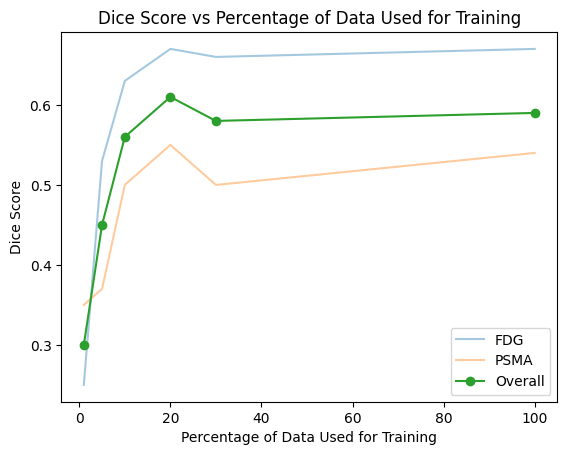

In [14]:
import matplotlib.pyplot as plt

fdg_dices = [.25, .53, .63, .67, .66, .67]
psma_dices =[.35, .37, .50, .55, .50, .54]
overall_dice = [.30, .45, .56, .61, .58, .59]
percentage_of_data =[1, 5, 10, 20, 30, 100]

plt.plot(percentage_of_data, fdg_dices, label='FDG', alpha=0.4)
plt.plot(percentage_of_data, psma_dices, label='PSMA', alpha =0.4)
plt.plot(percentage_of_data, overall_dice, label='Overall', marker ="o")
plt.xlabel('Percentage of Data Used for Training')
plt.ylabel('Dice Score')
plt.title('Dice Score vs Percentage of Data Used for Training')
plt.legend()


In [43]:
# Read splits for 10 percent
with open('./nnUNet_processed/Dataset999_Autopet/splits_final_10_percent.json', 'r') as f:
    data = json.load(f)
hard_masks = [x + ".nii.gz" for x in data[0]['train']]

# directory of original masks 
original_masks_dir = "/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr"
predicted_masks_dir = "/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_10/train_predictions/"

original_mask_files = os.listdir(original_masks_dir)
predicted_mask_files = [x for x in os.listdir(predicted_masks_dir) if ".nii.gz" in x]
# find the intersection of hard masks and original masks

intersection = set(hard_masks) & set(original_mask_files)
hard_mask_dirs = [os.path.join(original_masks_dir, x) for x in intersection]
predicted_trained_dirs = [os.path.join(predicted_masks_dir, x) for x in intersection]

assert len(intersection) == len(hard_masks) == len(hard_mask_dirs)


In [45]:
import shutil
from pathlib import Path

PREDICTED_TRAIN_DIR = Path(predicted_masks_dir) / "predicted_trained"
PREDICTED_TRAIN_DIR.mkdir(parents=True, exist_ok=True)

# Move prediction files that will be overwritten to backup folder
for prediction_on_train in predicted_trained_dirs:
    src = Path(prediction_on_train)
    dst = PREDICTED_TRAIN_DIR / src.name

    if src.is_file():
        shutil.move(str(src), str(dst))
        print(f"📦 Moved  : {src.name} → predicted_trained/")
    else:
        print(f"❌ NOT FOUND: {src}")

# Copy hard masks into predicted_masks_dir (overwriting)
for hard_mask in hard_mask_dirs:
    src = Path(hard_mask)
    dst = Path(predicted_masks_dir) / src.name

    if src.is_file():
        shutil.copy2(str(src), str(dst))
        print(f"✅ Copied  : {src.name} → predicted_masks_dir/")
    else:
        print(f"❌ NOT FOUND: {src}")

FileNotFoundError: [Errno 2] No such file or directory: '\\lab\\B\\BhattacharyaI\\Results\\nnUNet_data\\nnUNet_results\\Dataset999_AutoPet\\autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres\\fold_10\\train_predictions\\predicted_trained\\fdg_b92d7f441e_03-22-2007-NA-PET-CT Ganzkoerper  primaer mit KM-93813.nii.gz'

In [ ]:
print(os.path.exists(r'\\lab\B\BhattacharyaI\Results'))

In [29]:
predicted_mask_files = [x for x in os.listdir(predicted_masks_dir) if ".nii.gz" in x]

In [12]:
import json
import os

SPLITS_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_Autopet/splits_final.json'
TRAIN_FILES_DIR = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr'
TRAIN_LINK_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_Autopet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/train_link/'
# Load the json
with open(SPLITS_DIR, 'r') as f:
    splits = json.load(f)

# Get labelled and all filenames
labelled = set(splits[0]['train'])
all_files = set(splits[6]['train'])

# Get unlabelled only
unlabelled = all_files - labelled

# # Base directory where the actual files are located
base_dir = TRAIN_FILES_DIR
# os.listdir(base_dir)
# # Create the output folder
output_dir = TRAIN_LINK_DIR
os.makedirs(output_dir, exist_ok=True)

# # Create symlinks
for fname in unlabelled: 
    # add _0000 and _0001 to the filename for image and label respectively
    fname_pet = fname + '_0000.nii.gz'  # <-- CHANGE EXTENSION IF NEEDED
    fname_ct = fname + '_0001.nii.gz'  #
    # Adjust extension if needed
    
    src = os.path.join(base_dir, fname_pet)  # Assuming images are in base_dir
    dst = os.path.join(output_dir, fname_pet)  # Link will be created in output_dir    
    
    if os.path.exists(src):
        os.symlink(src, dst)
    else:
        print(f'File not found: {os.path.basename(src)}')
    
    src_2 = os.path.join(base_dir, fname_ct)  # Assuming images are in base_dir
    dst_2 = os.path.join(output_dir, fname_ct)  # Link will be created in output_dir
    
    if os.path.exists(src_2):
        os.symlink(src_2, dst_2)
    else:
        print(f'File not found: {os.path.basename(src_2)}')
    

print(f'Done! Created {len(unlabelled)} symlinks in {output_dir}')

PermissionError: [WinError 5] Access is denied: '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr\\fdg_c018b45a49_11-26-2006-NA-PET-CT Ganzkoerper  primaer mit KM-81137_0000.nii.gz' -> '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_Autopet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/train_link/fdg_c018b45a49_11-26-2006-NA-PET-CT Ganzkoerper  primaer mit KM-81137_0000.nii.gz'

In [11]:
for fname in unlabelled: 
    # add _0000 and _0001 to the filename for image and label respectively
    fname_pet = fname.replace('.nii.gz', '_0000.nii.gz')  # <-- CHANGE EXTENSION IF NEEDED
    fname_ct = fname.replace('.nii.gz', '_0001.nii.gz')  #
    # Adjust extension if needed
    print(fname_pet)

fdg_c018b45a49_11-26-2006-NA-PET-CT Ganzkoerper  primaer mit KM-81137
fdg_32aa845af1_06-15-2007-NA-PET-CT Ganzkoerper  primaer mit KM-95846
fdg_7d8aa1e94d_10-04-2002-NA-PET-CT Ganzkoerper  primaer mit KM-89111
fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerper  primaer mit KM-65884
fdg_5ac322455f_05-26-2003-NA-PET-CT Ganzkoerper  primaer mit KM-53199
fdg_ca62984a81_08-07-2003-NA-PET-CT Ganzkoerper  primaer mit KM-24067
psma_ca36bd95b63289d0_2020-05-15
psma_0908b747558fc03e_2019-11-02
fdg_0f44cec2e6_09-07-2003-NA-PET-CT Ganzkoerper  primaer mit KM-99224
fdg_12025abab5_11-01-2004-NA-PET-CT Ganzkoerper  primaer mit KM-18831
fdg_5cf118ac06_02-28-2004-NA-PET-CT Ganzkoerper  primaer mit KM-95778
psma_0a3fdc59c5e700d8_2017-12-31
fdg_41bd54f97a_03-25-2007-NA-PET-CT Ganzkoerper  primaer mit KM-02055
psma_7bf1123c2e71a6f9_2018-02-09
fdg_eeeda112bb_06-07-2003-NA-PET-CT Ganzkoerper  primaer mit KM-99935
fdg_06e7c24059_04-22-2005-NA-PET-CT Ganzkoerper  primaer mit KM-97021
fdg_75210090cd_07-02-2005-NA

In [10]:
print(os.listdir(base_dir))

['psma_7e76841f3c9623c0_2016-01-23_0001.nii.gz', 'fdg_605369e88d_09-15-2002-NA-PET-CT Ganzkoerper  primaer mit KM-20636_0001.nii.gz', 'fdg_6efefcb92a_03-26-2005-NA-PET-CT Ganzkoerper  primaer mit KM-24165_0001.nii.gz', 'fdg_8b40e356dc_06-18-2007-NA-PET-CT Ganzkoerper nativ u. mit KM-04076_0000.nii.gz', 'fdg_d6a48a629d_03-06-2003-NA-PET-CT Ganzkoerper  primaer mit KM-61967_0000.nii.gz', 'fdg_64aff75516_10-16-2005-NA-PET-CT Ganzkoerper  primaer mit KM-66236_0001.nii.gz', 'psma_9abd0bb6d4259d4e_2015-10-22_0001.nii.gz', 'fdg_2d70838805_04-30-2007-NA-PET-CT Ganzkoerper  primaer mit KM-77347_0001.nii.gz', 'fdg_176bdc5388_06-22-2006-NA-PET-CT Ganzkoerper  primaer mit KM-71560_0000.nii.gz', 'fdg_87afc291ec_07-20-2003-NA-PET-CT Ganzkoerper nativ-60370_0000.nii.gz', 'fdg_62a78a061f_08-29-2005-NA-PET-CT Ganzkoerper  primaer mit KM-87956_0001.nii.gz', 'fdg_e09a20d8fc_03-16-2006-NA-PET-CT Ganzkoerper  primaer mit KM-62436_0001.nii.gz', 'fdg_44bf7dc508_07-25-2002-NA-PET-CT Ganzkoerper  primaer mit K

In [9]:
data[0]['train']

['psma_ddd1dd20149915fb_2019-05-27',
 'psma_f954cb7aa70b9dc2_2020-11-16',
 'psma_46cf1282a7648712_2019-04-19',
 'psma_4da96443cf212c5f_2020-08-31',
 'psma_7a522636008cf840_2020-07-31',
 'psma_0bf6ac34fa0c97c0_2017-07-07',
 'psma_652cdc5859bf667d_2017-04-28',
 'psma_8b9bd3dbbb1553f1_2019-02-02',
 'psma_37328a98c70706f3_2020-11-06',
 'psma_798b3279d6980a3b_2019-08-02',
 'psma_7e25beff54698eb8_2021-06-21',
 'psma_823a3a884418928b_2019-12-23',
 'psma_652cdc5859bf667d_2016-03-26',
 'psma_838c9340e85ca431_2015-05-31',
 'psma_416d9ff3295dafcb_2020-02-08',
 'psma_dc8b0fa3643a6878_2019-01-26',
 'psma_fd142797eb926383_2018-09-15',
 'psma_24f62f21c04402ec_2015-04-26',
 'psma_e3c4639102fe5c51_2020-09-25',
 'psma_53c3a9d0f51745b6_2018-05-19',
 'psma_b5a4134e681683c0_2018-10-05',
 'psma_313ff961c59ee5dc_2015-11-13',
 'psma_4c9d9614d81f3005_2019-10-04',
 'psma_b361fb9c2455deb9_2018-11-19',
 'psma_6c6ce41bbf51580b_2019-07-27',
 'psma_ede705184679888a_2017-02-26',
 'psma_eda7ee31495b2bed_2020-09-07',
 

In [5]:
# load in a random file that is not a hard mask and plot it over the original image to check if it is correct
import numpy as np
segmentations = os.listdir('./nnUNet_processed/Dataset999_Autopet/nnUNetPlans_3d_fullres/')
# segmentation = np.load(os.path.join('./nnUNet_processed/Dataset999_Au|topet/nnUNetPlans_3d_fullres/', segmentations[0]))
psma_files = [x for x in segmentations if 'psma' in x]



In [9]:
# sample like 5 random ones
custom_files = psma_files[:5]
# sample their names
custom_files = [x[:32] + "_seg.npy" for x in custom_files]


In [10]:
custom_files

['psma_69ea0c011af2e2d4_2014-05-01_seg.npy',
 'psma_ee0aaecb8ed1c922_2021-12-18_seg.npy',
 'psma_1d7ce562612262cb_2019-08-09_seg.npy',
 'psma_0f434739488a6988_2017-11-03_seg.npy',
 'psma_6ef5e5c442e4ce63_2018-09-01_seg.npy']

In [ ]:
# plot the seg_org and the seg_original and the seg_npy side by side
import matplotlib.pyplot as plt

for custom_file in custom_files:
    # get the seg_org, seg_original and seg_npy file paths
    seg = np.load(os.path.join('./nnUNet_processed/Dataset999_Autopet/nnUNetPlans_3d_fullres/', custom_file))[0]
    seg_seg = np.load(os.path.join('./nnUNet_processed/Dataset999_Autopet/nnUNetPlans_3d_fullres/', custom_file.replace('_seg.npy', '_seg_original.npy')))[0]
    # print shapes
    print(f"seg_org shape: {seg_org.shape}")
    print(f"seg_original shape: {seg_original.shape}")
    print(f"seg_seg shape: {seg_seg.shape}")
    
    # plot the three side by side the z projection of them 
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(np.max(seg_org, axis=0), cmap='gray')
    plt.title('seg_org (predicted)')
    plt.subplot(1,3,2)
    plt.imshow(np.max(seg_original, axis=0), cmap='gray')
    plt.title('seg_original (hard mask)')
    plt.subplot(1,3,3)
    plt.imshow(np.max(seg_seg, axis=0), cmap='gray')
    plt.title('seg.npy (predicted mask)')
    plt.show() 


NameError: name 'seg_org' is not defined

In [ ]:
#

# Visualize different labels and see how they look 

In [ ]:
original_masks_dir = "/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr"
check_directory = "/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_raw/Dataset1000_AutoPet/labelsTr/"

example_file = "psma_f33cbe53d1aee5e8_2018-01-13"
# example_file = "psma_36c6b5674abe9d32_2018-08-31"
# example_file = "fdg_0af7ffe12a_08-12-2005-NA-PET-CT Ganzkoerper  primaer mit KM-96698"
# load the original mask and the predicted mask and plot them side by side
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np
# check if the check_directory exists
assert os.path.exists(check_directory), f"Directory {check_directory} does not exist"


original_mask = nib.load(os.path.join(original_masks_dir, example_file + ".nii.gz")).get_fdata()
check_mask = np.load(os.path.join(check_directory, example_file + "_seg.npy"))[0]


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(np.max(original_mask, axis=2), cmap='gray')
plt.title('Original Mask')
plt.subplot(1,2,2)  
plt.imshow(np.max(check_mask, axis=0), cmap='gray')
plt.title('Predicted Mask (npy)')

AssertionError: Directory /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_raw/Dataset999_AutoPet/labelsTr/ does not exist

In [3]:
import json
import os

print(os.getcwd())

# ── Paths ──────────────────────────────────────────────────────────────────────
SPLITS_DIR        = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/splits_final.json'

# Source directories
HARD_LABELS_DIR    = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/nnUNetPlans_3d_fullres/'
PSEUDO_LABELS_DIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/train_tta_predicted/train_predicted/converted_segs'
VAL_LABELS_DIR    = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/nnUNetPlans_3d_fullres/'
TEST_LABELS_DIR  = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/test/'

# Destination
DATASET_ID        = 901   # <-- CHANGE AS NEEDED
NNUNET_RAW_DIR    = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/'
NEW_DATASET_DIR   = os.path.join(NNUNET_RAW_DIR, f'Dataset{DATASET_ID:03d}_AutoPet')
OUTPUT_LABELS_DIR = os.path.join(NEW_DATASET_DIR, 'labelsTr')

# ── Load splits ────────────────────────────────────────────────────────────────
with open(SPLITS_DIR, 'r') as f:
    splits = json.load(f)

labelled   = set(splits[0]['train'])
all_files  = set(splits[6]['train'])
unlabelled = all_files - labelled
val_files  = set(splits[0]['val'])

# print(os.listdir(TEST_LABELS_DIR)[:5])
# test_files = [f.replace('.npy', '') for f in os.listdir(TEST_LABELS_DIR) if f.endswith('.npy')]
# ── Create output directory ────────────────────────────────────────────────────
os.makedirs(OUTPUT_LABELS_DIR, exist_ok=True)
print(f'Created dataset directory: {NEW_DATASET_DIR}')

# ── Helper ─────────────────────────────────────────────────────────────────────
def make_symlink(src: str, dst: str) -> None:
    """
    Create a symlink at `dst` pointing to `src`.
    Skips gracefully if the source does not exist or the link already exists.
    """
    if not os.path.exists(src):
        print(f'  [MISSING]  {os.path.basename(src)}')
        return
    if os.path.exists(dst) or os.path.islink(dst):
        print(f'  [EXISTS]   {os.path.basename(dst)}')
        return
    os.symlink(src, dst)


def link_label(fname: str, source_dir: str) -> None:
    """Symlink a single label file from `source_dir` into OUTPUT_LABELS_DIR."""
    filename = fname + '.npy'
    src = os.path.join(source_dir, filename)
    dst = os.path.join(OUTPUT_LABELS_DIR, filename)
    make_symlink(src, dst)

total = 0 

# ── 1. Hard (ground-truth) labels  ────────────────────────────────────────────
print('\n── Linking hard labels ──')
for fname in labelled:
    link_label(fname, HARD_LABELS_DIR)
print(f'  Processed {len(labelled)} hard label(s).')
total += len(labelled)

# # ── 2. Pseudo labels (unlabelled cases) ───────────────────────────────────────
# print('\n── Linking pseudo labels ──')
# for fname in unlabelled:
#     link_label(fname, PSEUDO_LABELS_DIR)
# print(f'  Processed {len(unlabelled)} pseudo label(s).')
# total += len(unlabelled)

# # ── 3. Validation labels ──────────────────────────────────────────────────────
# print('\n── Linking validation labels ──')
# for fname in val_files:
#     link_label(fname, VAL_LABELS_DIR)
# print(f'  Processed {len(val_files)} validation label(s).')
# total += len(val_files)

# ── 4. Test labels ─────────────────────────────────────────────────────────────
# print('\n── Linking test labels ──')
# for fname in test_files:
#     link_label(fname, TEST_LABELS_DIR)
# print(f'  Processed {len(test_files)} test label(s).')
# total += len(test_files)

# ── Summary ───────────────────────────────────────────────────────────────────

print(f'\nDone! Created up to {total} symlink(s) in:\n  {OUTPUT_LABELS_DIR}')

\\dartfs\rc\lab\B\BhattacharyaI\Results\Biratal\nnUNet
Created dataset directory: //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet

── Linking hard labels ──
  [MISSING]  fdg_63508c679d_02-17-2005-NA-PET-CT Ganzkoerper  primaer mit KM-71545.npy
  [MISSING]  fdg_f1ca0f7c4c_12-22-2001-NA-PET-CT Ganzkoerper  primaer mit KM-21488.npy
  [MISSING]  fdg_979f9c3dba_06-22-2006-NA-PET-CT Ganzkoerper  primaer mit KM-59545.npy
  [MISSING]  psma_4c9d9614d81f3005_2019-10-04.npy
  [MISSING]  fdg_b42adab18e_09-05-2003-NA-PET-CT Ganzkoerper  primaer mit KM-60746.npy
  [MISSING]  fdg_f650c87621_12-08-2005-NA-PET-CT Ganzkoerper  primaer mit KM-18719.npy
  [MISSING]  psma_46cf1282a7648712_2019-04-19.npy
  [MISSING]  psma_823a3a884418928b_2019-12-23.npy
  [MISSING]  fdg_f7a9267a69_11-01-2002-NA-PET-CT Ganzkoerper nativ-75431.npy
  [MISSING]  fdg_ac700ab4db_12-04-2004-NA-PET-CT Ganzkoerper  primaer mit KM-73358.npy
  [MISSING]  fdg_af73b85f2c_06-19-2003-NA-PET-CT Ganzk